Step 1 — Load Data

In [1]:
import sys
import os

import pandas as pd
# Add project root directory to Python path
sys.path.append(os.path.abspath(".."))


df = pd.read_csv("../data/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Summarization
Check Data Types

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Descriptive Statistics

In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

Descriptive Statistics

In [6]:
df[['age',
    'bmi',
    'children',
    'charges']].describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Meaning of  Columns

| Column   | Meaning                       |
| -------- | ----------------------------- |
| age      | customer age                  |
| bmi      | Body Mass Index               |
| children | number of children/dependents |
| smoker   | whether customer smokes       |
| region   | residential region            |
| charges  | medical insurance cost        |


## Descriptive Statistics Interpretation

The descriptive statistics analysis provides important insights into customer demographics, health conditions, family size, and insurance charges within the dataset.

### Age Distribution
The average customer age is approximately 39 years, with ages ranging from 18 to 64 years. The relatively balanced distribution suggests that the dataset includes both younger and older individuals, allowing for broader insurance risk analysis across different age groups.

The standard deviation of 14.05 indicates moderate variability in customer ages.

---

### BMI (Body Mass Index) Analysis
The average BMI is approximately 30.66, which falls within the obesity range according to standard BMI classifications.

BMI values range from 15.96 to 53.13, showing substantial variation in customer health conditions. The high maximum BMI suggests the presence of individuals with severe obesity, which may significantly increase medical insurance costs.

The relatively large standard deviation indicates notable differences in customer lifestyle and health risk factors.

---

### Children/Dependents Analysis
The average number of children is approximately 1.09, meaning most customers have relatively small family sizes.

The majority of customers have between 0 and 2 children, while a few customers have up to 5 dependents. This suggests that family size varies moderately across the dataset.

---

### Insurance Charges Analysis
Insurance charges exhibit substantial variability across customers.

- The average insurance charge is approximately 13,270.
- The median charge is approximately 9,382.
- The maximum charge exceeds 63,770.

The large difference between the mean and median suggests that the distribution of insurance charges is positively skewed, meaning a small number of customers incur extremely high medical costs.

Additionally, the very high standard deviation confirms the presence of significant variation in insurance expenses.

This may indicate that certain factors such as:
- smoking behavior,
- high BMI,
- older age,
- or chronic health conditions

strongly influence insurance costs.

---

## Overall Insights

The dataset demonstrates considerable diversity in:
- customer age,
- health condition (BMI),
- family size,
- and medical insurance expenses.

The presence of extremely high insurance charges suggests potential outliers and high-risk individuals within the dataset.

These findings indicate that demographic and health-related variables may play an important role in predicting insurance charges and understanding insurance risk patterns.

## Data Quality Assessment
Missing Values

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [9]:
df.groupby('smoker')['charges'].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

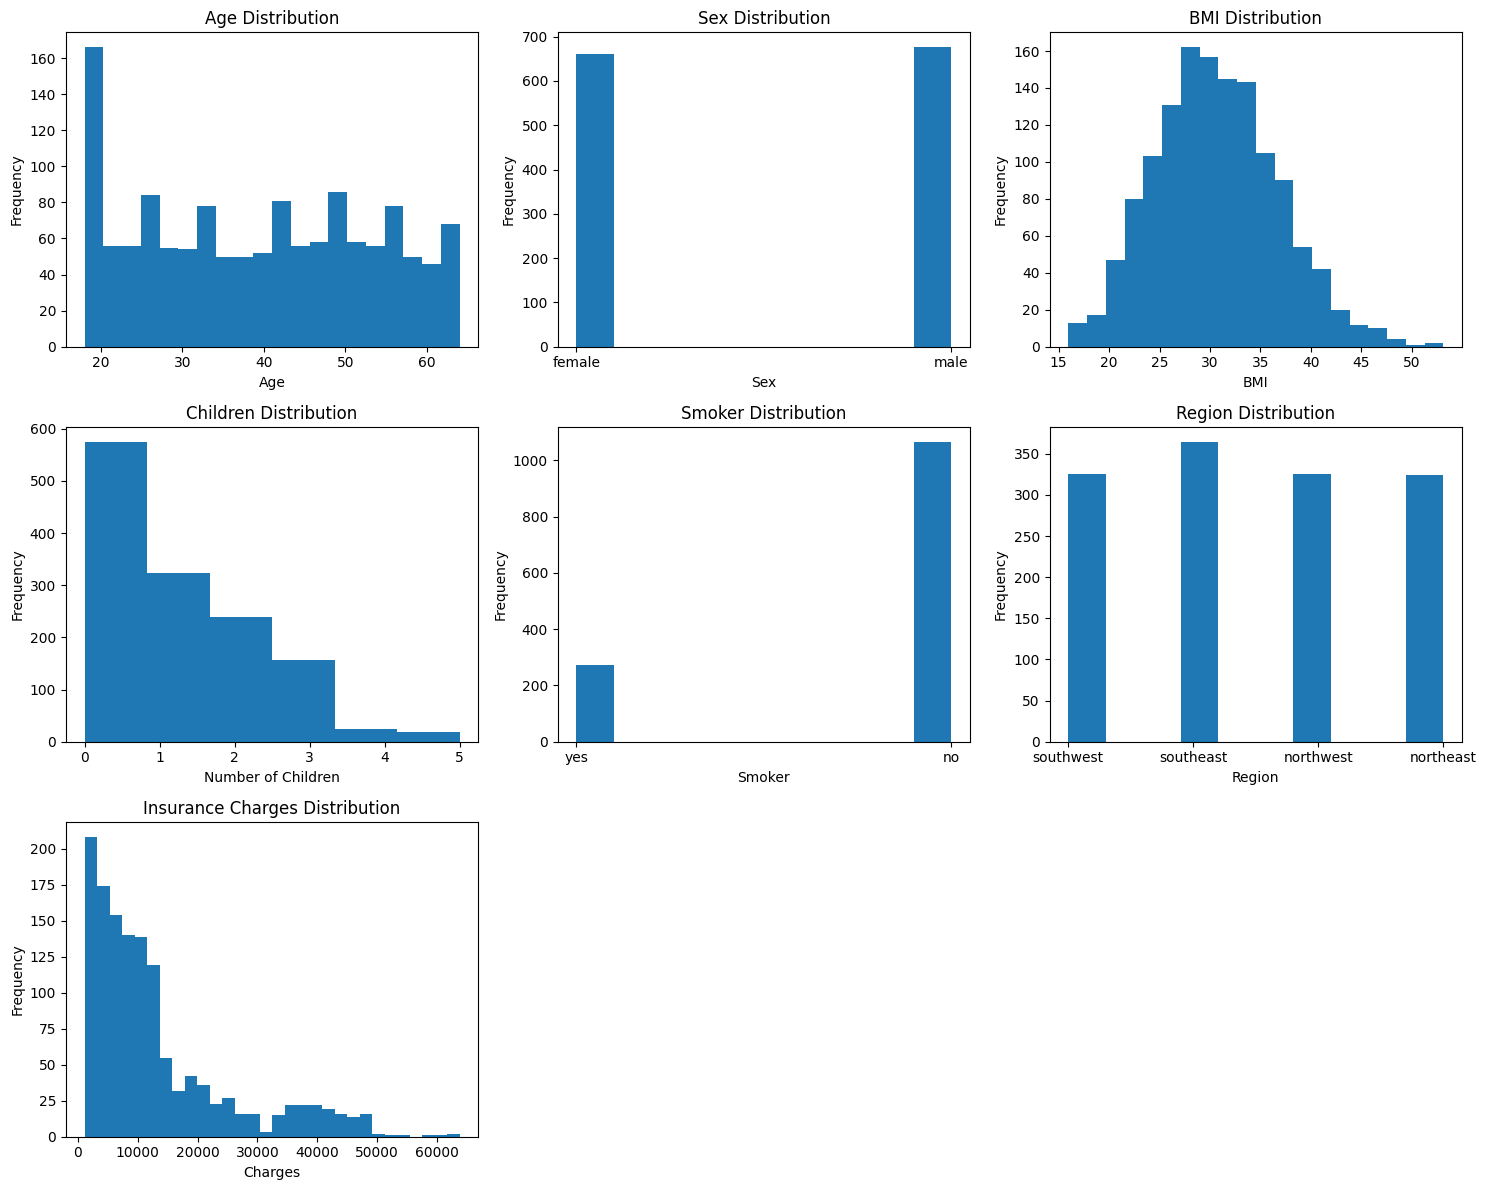

In [10]:
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Age Histogram
axes[0,0].hist(df['age'], bins=20)
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')

# Sex Histogram
axes[0,1].hist(df['sex'])
axes[0,1].set_title('Sex Distribution')
axes[0,1].set_xlabel('Sex')
axes[0,1].set_ylabel('Frequency')

# BMI Histogram
axes[0,2].hist(df['bmi'], bins=20)
axes[0,2].set_title('BMI Distribution')
axes[0,2].set_xlabel('BMI')
axes[0,2].set_ylabel('Frequency')

# Children Histogram
axes[1,0].hist(df['children'], bins=6)
axes[1,0].set_title('Children Distribution')
axes[1,0].set_xlabel('Number of Children')
axes[1,0].set_ylabel('Frequency')

# Smoker Histogram
axes[1,1].hist(df['smoker'])
axes[1,1].set_title('Smoker Distribution')
axes[1,1].set_xlabel('Smoker')
axes[1,1].set_ylabel('Frequency')

# Region Histogram
axes[1,2].hist(df['region'])
axes[1,2].set_title('Region Distribution')
axes[1,2].set_xlabel('Region')
axes[1,2].set_ylabel('Frequency')

# Charges Histogram
axes[2,0].hist(df['charges'], bins=30)
axes[2,0].set_title('Insurance Charges Distribution')
axes[2,0].set_xlabel('Charges')
axes[2,0].set_ylabel('Frequency')

# Remove empty subplots
fig.delaxes(axes[2,1])
fig.delaxes(axes[2,2])

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

# Univariate Analysis

Univariate analysis was performed to understand the distribution and characteristics of individual variables in the insurance dataset.

## Age Distribution
The age distribution appears relatively balanced across different age groups, with a moderate concentration of customers between young adulthood and middle age. The dataset includes individuals ranging from 18 to 64 years old.

---

## Sex Distribution
The distribution of male and female customers appears relatively balanced, indicating that the dataset does not suffer from major gender imbalance.

---

## BMI Distribution
BMI values are concentrated around the range of 25–35, with many customers falling within overweight or obese categories. A few extreme BMI values indicate potential health-risk outliers.

---

## Children Distribution
Most customers have fewer children, particularly between 0 and 2 dependents. Larger family sizes are less common in the dataset.

---

## Smoker Distribution
Non-smokers represent the majority of customers, while smokers form a smaller proportion of the dataset. This variable is expected to significantly influence insurance charges.

---

## Region Distribution
Customers are distributed across multiple geographic regions with relatively balanced representation, supporting broader regional analysis.

---

## Insurance Charges Distribution
Insurance charges are positively skewed, with most customers having moderate medical costs while a smaller number experience extremely high charges.

The presence of high-cost outliers suggests that certain demographic or health-related factors strongly increase insurance expenses.

---

## Overall Insights

The univariate analysis revealed:
- balanced demographic representation,
- considerable variation in BMI and insurance charges,
- small average family sizes,
- and strong positive skewness in medical costs.

These findings provide important foundational insights for further bivariate analysis, correlation analysis, and predictive modeling.